<a href="https://colab.research.google.com/github/sagargupta005/resume/blob/master/Machine_Learning_all_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns detected: Index(['Corrected Sensor Dataset (500 Readings)', 'Unnamed: 1', 'Unnamed: 2'], dtype='object')

Cleaned Data:
  Reading  Temperature  Vibration
1       1        63.37       4.80
2       2        63.62       5.25
3       3        65.79       5.63
4       4        63.98       4.80
5       5        63.61       5.41


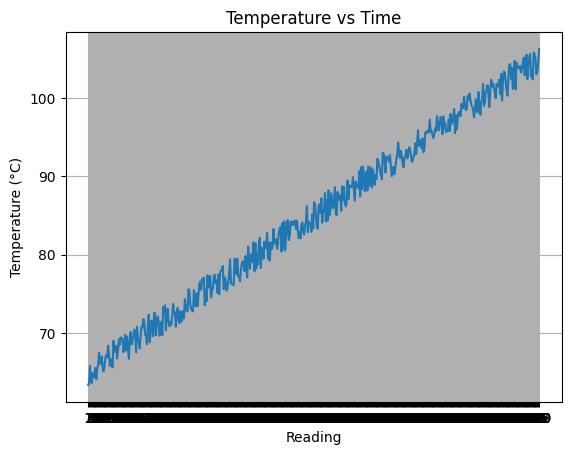

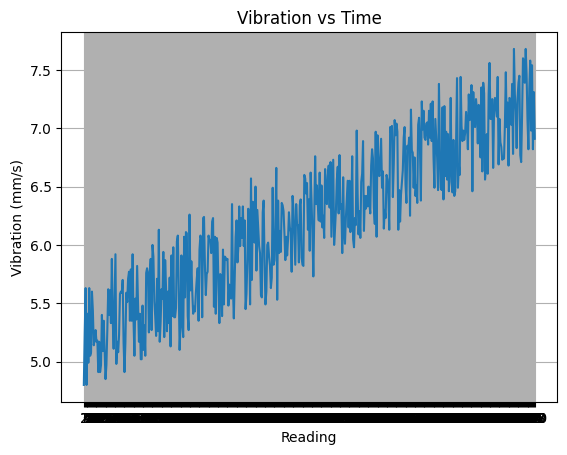

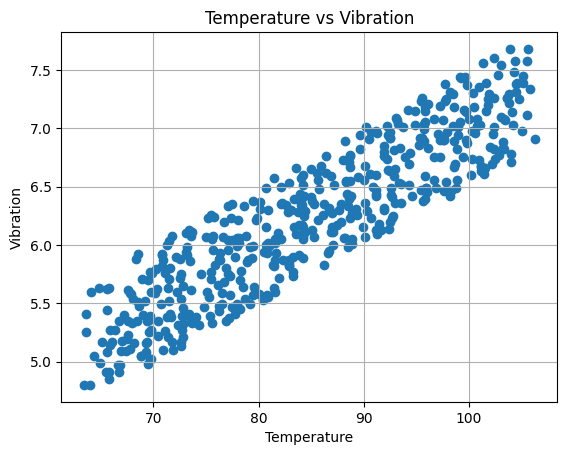

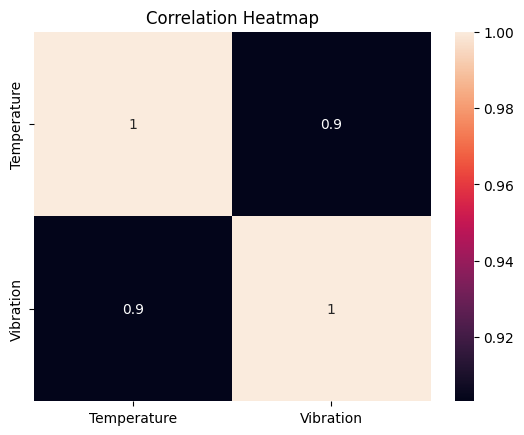

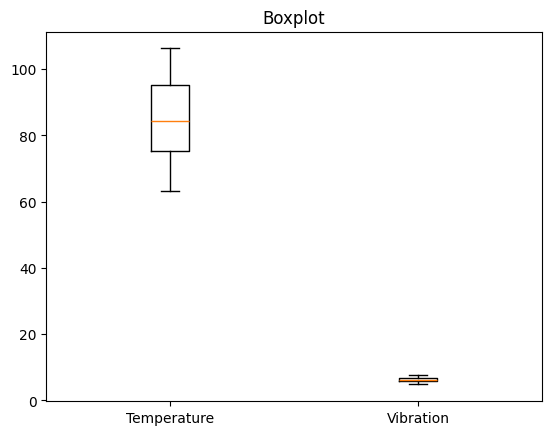


✅ SUCCESS: Everything working perfectly!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# STEP 1: LOAD DATA
# =========================
file_path = "500_corrected_readings.csv"
df = pd.read_csv(file_path)

print("Columns detected:", df.columns)

# =========================
# STEP 2: HANDLE 3-COLUMN DATA
# =========================
# Case 1: If 3 columns → Reading, Temp, Vib
if df.shape[1] == 3:
    df.columns = ["Reading", "Temperature", "Vibration"]

# Case 2: If 2 columns → Temp, Vib
elif df.shape[1] == 2:
    df.columns = ["Temperature", "Vibration"]
    df["Reading"] = range(1, len(df)+1)

else:
    raise Exception("❌ Unexpected format. Check your CSV file.")

# Convert to numeric (safety)
df["Temperature"] = pd.to_numeric(df["Temperature"], errors='coerce')
df["Vibration"] = pd.to_numeric(df["Vibration"], errors='coerce')

df = df.dropna()

print("\nCleaned Data:")
print(df.head())

# =========================
# STEP 3: EXTRACT DATA
# =========================
temps = df["Temperature"]
vibs = df["Vibration"]
readings = df["Reading"]

# =========================
# STEP 4: LINE GRAPHS
# =========================
plt.figure()
plt.plot(readings, temps)
plt.title("Temperature vs Time")
plt.xlabel("Reading")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

plt.figure()
plt.plot(readings, vibs)
plt.title("Vibration vs Time")
plt.xlabel("Reading")
plt.ylabel("Vibration (mm/s)")
plt.grid()
plt.show()

# =========================
# STEP 5: SCATTER
# =========================
plt.figure()
plt.scatter(temps, vibs)
plt.title("Temperature vs Vibration")
plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.grid()
plt.show()

# =========================
# STEP 6: HEATMAP
# =========================
plt.figure()
sns.heatmap(df[["Temperature","Vibration"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# STEP 7: BOXPLOT
# =========================
plt.figure()
plt.boxplot([temps, vibs])
plt.xticks([1,2], ["Temperature", "Vibration"])
plt.title("Boxplot")
plt.show()

print("\n✅ SUCCESS: Everything working perfectly!")


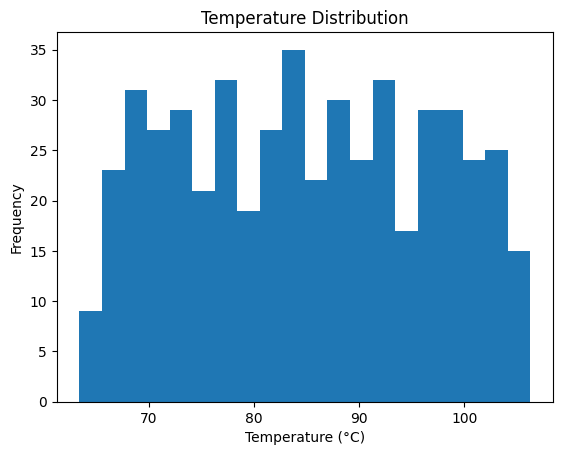

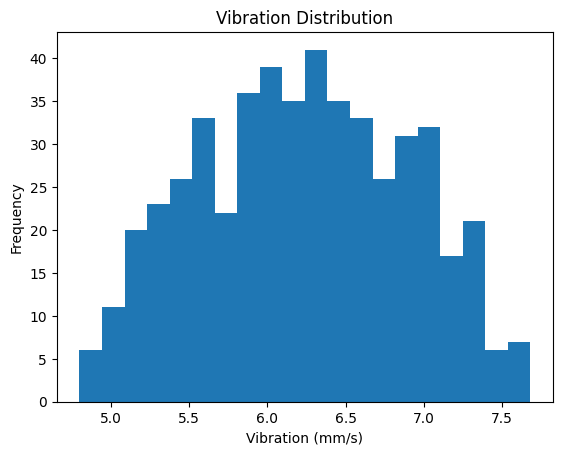

In [10]:
plt.figure()
plt.hist(temps, bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(vibs, bins=20)
plt.title("Vibration Distribution")
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Frequency")
plt.show()

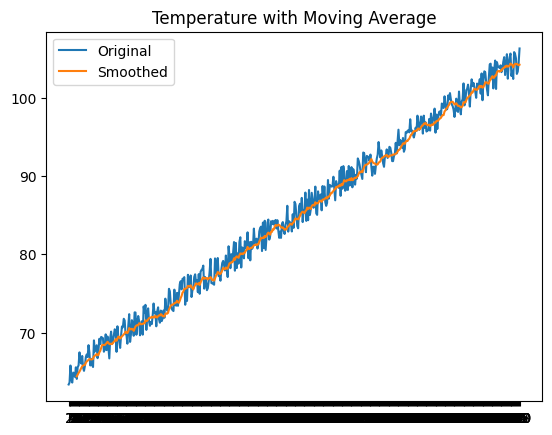

In [11]:
rolling_temp = temps.rolling(window=10).mean()

plt.figure()
plt.plot(readings, temps, label="Original")
plt.plot(readings, rolling_temp, label="Smoothed")
plt.legend()
plt.title("Temperature with Moving Average")
plt.show()

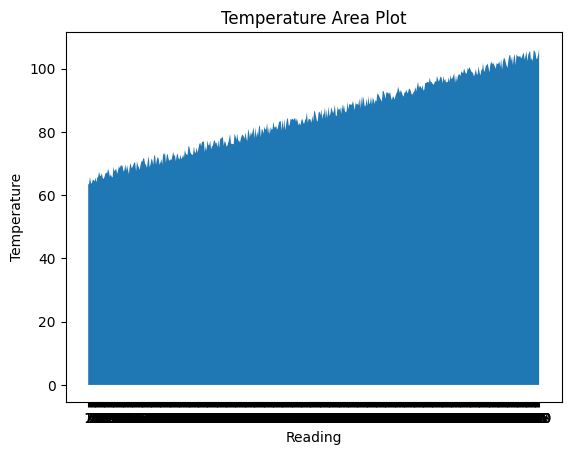

In [12]:
plt.figure()
plt.fill_between(readings, temps)
plt.title("Temperature Area Plot")
plt.xlabel("Reading")
plt.ylabel("Temperature")
plt.show()

MSE: 0.08155729916000157


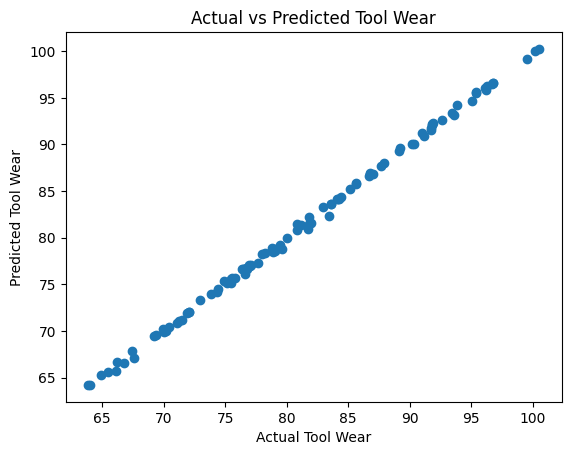

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("500_corrected_readings.csv")

# Fix columns (if 3 columns)
df.columns = ["Reading", "Temperature", "Vibration"]

# =========================
# FIX DATA TYPE (IMPORTANT)
# =========================
df["Temperature"] = pd.to_numeric(df["Temperature"], errors='coerce')
df["Vibration"] = pd.to_numeric(df["Vibration"], errors='coerce')

df = df.dropna()

# =========================
# CREATE TOOL WEAR
# =========================
df["Tool_Wear"] = (df["Temperature"] * 0.6 + df["Vibration"] * 5)

# =========================
# FEATURES & TARGET
# =========================
X = df[["Temperature", "Vibration"]]
y = df["Tool_Wear"]

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# =========================
# MODEL
# =========================
model = RandomForestRegressor()
model.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
y_pred = model.predict(X_test)

# =========================
# RESULT
# =========================
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# =========================
# GRAPH
# =========================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Tool Wear")
plt.ylabel("Predicted Tool Wear")
plt.title("Actual vs Predicted Tool Wear")
plt.show()

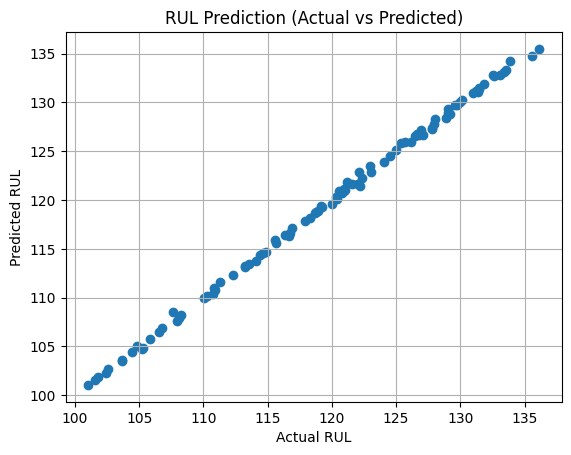

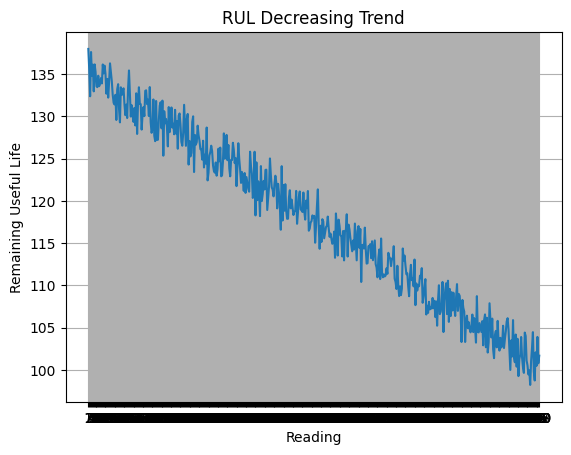

✅ RUL Prediction Completed


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# =========================
# STEP 1: LOAD DATA
# =========================
df = pd.read_csv("500_corrected_readings.csv")

# Fix columns
df.columns = ["Reading", "Temperature", "Vibration"]

# Convert to numeric
df["Temperature"] = pd.to_numeric(df["Temperature"], errors='coerce')
df["Vibration"] = pd.to_numeric(df["Vibration"], errors='coerce')
df = df.dropna()

# =========================
# STEP 2: CREATE TOOL WEAR
# =========================
df["Tool_Wear"] = (df["Temperature"] * 0.6 + df["Vibration"] * 5)

# =========================
# STEP 3: CREATE RUL
# =========================
MAX_LIFE = 200   # you can change this

df["RUL"] = MAX_LIFE - df["Tool_Wear"]

# Avoid negative values
df["RUL"] = df["RUL"].clip(lower=0)

# =========================
# STEP 4: FEATURES & TARGET
# =========================
X = df[["Temperature", "Vibration"]]
y = df["RUL"]

# =========================
# STEP 5: TRAIN MODEL
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

# =========================
# STEP 6: PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# STEP 7: GRAPH
# =========================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("RUL Prediction (Actual vs Predicted)")
plt.grid()
plt.show()

# =========================
# STEP 8: RUL TREND
# =========================
plt.figure()
plt.plot(df["Reading"], df["RUL"])
plt.xlabel("Reading")
plt.ylabel("Remaining Useful Life")
plt.title("RUL Decreasing Trend")
plt.grid()
plt.show()

print("✅ RUL Prediction Completed")